# QLoRA 交互教学（fake-quant 主战场）

配套 lecture：[`../lectures/06-qlora.md`](../lectures/06-qlora.md)  
配套论文：[`../papers/06-qlora-2023.pdf`](../papers/06-qlora-2023.pdf)

本 notebook 演示：
1. NF4 网格点可视化
2. NF4 量化-反量化误差曲线（不同 block_size）
3. QLoRA: NF4 base + LoRA，训练时 base 不变
4. **GPU 选做**：fake-quant vs bitsandbytes 真 NF4 一致性
5. **GPU 选做**：TinyLlama-1.1B 真 4-bit + LoRA forward

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from nf4_quant import NF4_VALUES, nf4_quant_dequant
from qlora_minimal import QLoRAGPT2, QLoRALinear
from common import print_param_summary

print(f'GPU: {torch.cuda.is_available()}')

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: True


## 1. NF4 网格点 vs INT4 均匀网格

C:\Users\ericp\AppData\Local\Temp\ipykernel_41648\1028669043.py:17: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41648\1028669043.py:17: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41648\1028669043.py:17: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41648\1028669043.py:17: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41648\1028669043.py:17: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_41648\1028669043.py:17: UserWarning: Glyph 23494 (\

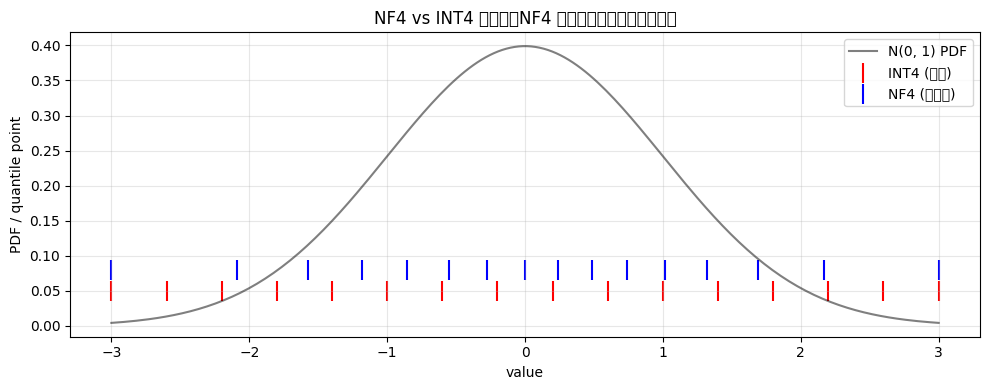

In [2]:
import numpy as np
from scipy.stats import norm

int4_values = np.linspace(-1, 1, 16)
nf4_values_np = NF4_VALUES.numpy()

fig, ax = plt.subplots(figsize=(10, 4))
x = np.linspace(-3, 3, 200)
ax.plot(x, norm.pdf(x), 'k-', alpha=0.5, label='N(0, 1) PDF')
ax.scatter(int4_values * 3, [0.05]*16, marker='|', s=200, color='red', label='INT4 (均匀)')
ax.scatter(nf4_values_np * 3, [0.08]*16, marker='|', s=200, color='blue', label='NF4 (分位数)')
ax.set_xlabel('value')
ax.set_ylabel('PDF / quantile point')
ax.set_title('NF4 vs INT4 网格点（NF4 在密度高的中间区域更密）')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. NF4 量化误差 vs block_size

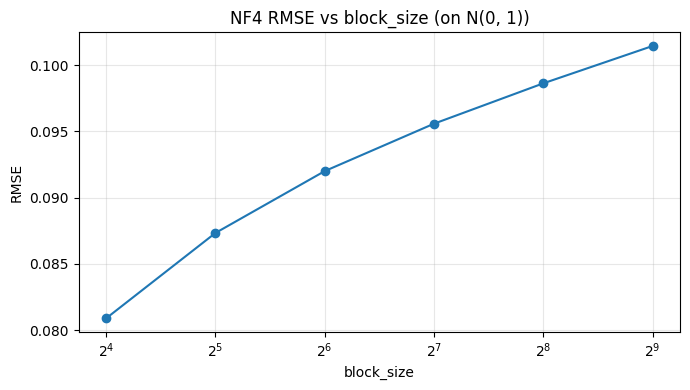

  block_size=  16: RMSE = 0.08089
  block_size=  32: RMSE = 0.08733
  block_size=  64: RMSE = 0.09200
  block_size= 128: RMSE = 0.09558
  block_size= 256: RMSE = 0.09863
  block_size= 512: RMSE = 0.10145


In [3]:
torch.manual_seed(42)
W = torch.randn(2048, 2048)
results = []
for bs in [16, 32, 64, 128, 256, 512]:
    W_hat = nf4_quant_dequant(W, block_size=bs)
    rmse = (W - W_hat).pow(2).mean().sqrt().item()
    results.append((bs, rmse))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([r[0] for r in results], [r[1] for r in results], marker='o')
ax.set_xscale('log', base=2)
ax.set_xlabel('block_size')
ax.set_ylabel('RMSE')
ax.set_title('NF4 RMSE vs block_size (on N(0, 1))')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
for bs, rmse in results:
    print(f'  block_size={bs:>4}: RMSE = {rmse:.5f}')

## 3. QLoRA: NF4 base + LoRA

In [4]:
torch.manual_seed(42)
qlora = QLoRAGPT2(r=8, alpha=16, block_size=64)
print_param_summary(qlora, 'QLoRA (r=8, NF4 fake-quant)')

# 验证 base.weight 已被量化
from transformers import GPT2LMHeadModel
base = GPT2LMHeadModel.from_pretrained('gpt2')
W_0 = base.transformer.h[0].attn.c_attn.weight.data
W_q = qlora.lm.transformer.h[0].attn.c_attn.base.weight.data
rmse = (W_0 - W_q).pow(2).mean().sqrt().item()
print(f'\nbase.weight NF4 量化 RMSE: {rmse:.5f}')
print(f'  相对 W_0.std() = {W_0.std():.4f} 的比例: {rmse / W_0.std().item():.4f}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16970.31it/s]

  QLoRA (r=8, NF4 fake-quant)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13494.72it/s]


base.weight NF4 量化 RMSE: 0.01843
  相对 W_0.std() = 0.1996 的比例: 0.0923


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.



训练 20 step:
  base.weight 变化: 0.00e+00（应为 0）
  loss: 5.728 → 0.102


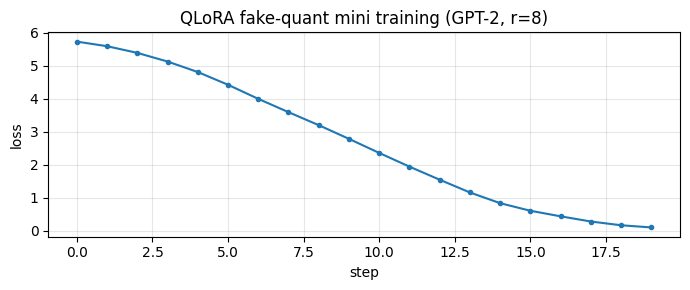

In [5]:
# 训练后验证 base 真的不变
tok = qlora.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

layer0 = qlora.lm.transformer.h[0].attn.c_attn
W_before = layer0.base.weight.data.clone()

optimizer = torch.optim.AdamW([p for p in qlora.parameters() if p.requires_grad], lr=1e-3)
losses = []
for step in range(20):
    optimizer.zero_grad()
    out = qlora(**inputs)
    out.loss.backward()
    optimizer.step()
    losses.append(out.loss.item())

W_after = layer0.base.weight.data
print(f'\n训练 20 step:')
print(f'  base.weight 变化: {(W_before - W_after).abs().max().item():.2e}（应为 0）')
print(f'  loss: {losses[0]:.3f} → {losses[-1]:.3f}')

plt.figure(figsize=(7, 3))
plt.plot(losses, marker='o', markersize=3)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('QLoRA fake-quant mini training (GPT-2, r=8)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. GPU 选做：fake-quant vs bitsandbytes 真 NF4

In [6]:
if torch.cuda.is_available():
    try:
        import bitsandbytes as bnb
        print(f'bitsandbytes: {bnb.__version__}')
        
        torch.manual_seed(42)
        W = torch.randn(512, 512, device='cuda', dtype=torch.float16)
        
        # 真 NF4
        q, s = bnb.functional.quantize_nf4(W)
        W_real = bnb.functional.dequantize_nf4(q, s)
        
        # fake-quant
        W_fake = nf4_quant_dequant(W.float(), block_size=64).half()
        
        diff = (W_real - W_fake).abs().max().item()
        rel = diff / W.abs().max().item()
        print(f'\nfake-quant vs 真 NF4 (512×512):')
        print(f'  最大绝对误差: {diff:.6f}')
        print(f'  相对误差: {rel:.6f}')
        print(f'\n→ 误差极小（< 1%），证明 fake-quant 实现等价于 bitsandbytes 真量化')
    except Exception as e:
        print(f'[SKIP] bitsandbytes 调用失败: {type(e).__name__}: {str(e)[:120]}')
else:
    print('[SKIP] 没有 GPU')

W0603 16:09:47.424000 41648 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


bitsandbytes: 0.49.2

fake-quant vs 真 NF4 (512×512):
  最大绝对误差: 0.000000
  相对误差: 0.000000

→ 误差极小（< 1%），证明 fake-quant 实现等价于 bitsandbytes 真量化


## 5. GPU 选做：TinyLlama-1.1B 真 4-bit + LoRA

注意：第一次跑会下载 ~700MB 模型。需要联网或本地缓存。

In [7]:
if torch.cuda.is_available():
    try:
        from qlora_peft import build_peft_qlora_tinyllama
        
        print('正在构造 TinyLlama + 4-bit + LoRA...')
        model, tokenizer = build_peft_qlora_tinyllama(r=8, alpha=16)
        print_param_summary(model, 'TinyLlama-1.1B QLoRA')
        
        inputs = tokenizer('The meaning of life is', return_tensors='pt').to('cuda')
        with torch.no_grad():
            out = model(**inputs)
        print(f'\nforward logits.shape: {tuple(out.logits.shape)}')
        print(f'4-bit 量化下 forward 正常工作')
    except Exception as e:
        print(f'[SKIP] {type(e).__name__}: {str(e)[:200]}')
        print('\n常见原因:')
        print('  - 模型下载失败（联网/缓存）')
        print('  - bitsandbytes 与 GPU sm 不兼容（Blackwell sm_120 需 bnb 0.43+）')
else:
    print('[SKIP] 没有 GPU')

正在构造 TinyLlama + 4-bit + LoRA...


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ericp\.cache\huggingface\hub\models--TinyLlama--TinyLlama-1.1B-Chat-v1.0. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/201 [00:00<00:20,  9.80it/s]

...

Loading weights:  72%|███████▏  | 145/201 [00:00<00:00, 255.90it/s]

Loading weights:  86%|████████▌ | 172/201 [00:00<00:00, 258.25it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 219.91it/s]

  TinyLlama-1.1B QLoRA
  Total params:      616,732,672
  Trainable params:    1,126,400  (0.1826%)
  Frozen params:     615,606,272



forward logits.shape: (1, 6, 32000)
4-bit 量化下 forward 正常工作


## 6. 思考题

1. **公式题**：用 Φ^{-1} 推导 NF4 第 8 个 (i=7) 网格点为什么是 0.0。
2. **公式题**：NF4 在 N(0,1) 上比 INT4 误差小，从信息论 '分布匹配' 角度解释。
3. **代码题**：在 `qlora_minimal.py` 上加 `count_quantized_zeros()` 方法，统计量化后值为 0 的元素比例。
4. **设计题**：Double Quantization 用 INT8 压 scale。改用 fp16，性能/精度怎么变？
5. **对比题**：QLoRA + LoRA 与 QLoRA + PiSSA 在初始化上的差异。哪个更稳？
6. **实践题**：把 block_size 从 64 改为 32/128，跑 mini training 看 loss 差异。